# Does a "belt-hold" candle actually reverse the trend? 🥋
### One famous candle — opens at its low, closes way up — meets a stopwatch

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Opening_extreme_reverses%3F: Busted](https://img.shields.io/badge/Opening_extreme_reverses%3F-Busted-8b949e?style=flat-square)

Open any candlestick guide and you'll find the **bullish belt-hold** (Japanese *yorikiri*, a sumo move meaning *to force out*). It's a single bar that **opens right at its low** — no lower wick at all — and then **closes well up** in a tall white body, after a downtrend. The lore, taught by Steve Nison and echoed everywhere, is that because the **open sat at the very bottom**, buyers grabbed control from the first tick and the down-move is about to **reverse**. So you buy.

It *looks* compelling on a hand-picked chart. But a single candle, spotted after the fact, on a market that drifts **up** anyway, is the textbook way to fool yourself. So we did the fair thing: encode the belt-hold **mechanically** (open at the low, tall body, real prior downtrend — no eyeballing), fire it hundreds of times across five indices over 21 years, and time the result — against the only baseline that matters: **buying on random days instead.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from belt_hold import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real belt-hold cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 666, 'fp_spy': '4cb5244f3990', 'h5': (5, 665, 31.8, 59, 2.36, 33.4, -1.7, 29.8, -0.11, 0.909), 'h10': (10, 665, 66.5, 62, 3.71, 57.2, 9.3, 64.5, 0.47, 0.635), 'h20': (20, 665, 104.6, 67, 3.68, 71.9, 32.8, 102.6, 1.15, 0.251), 'h60': (60, 660, 306.0, 69, 5.86, 212.1, 93.9, 304.0, 2.03, 0.042), 'per': [('SPY', 121, 119.5, 2.49, 22.4, 97.2), ('QQQ', 139, 126.6, 1.55, 160.1, -33.5), ('IWM', 126, 67.0, 1.04, 29.2, 37.8), ('DIA', 137, 89.8, 1.48, 62.6, 27.3), ('GLD', 143, 118.1, 2.56, 74.7, 43.4)], 'placebo': (119.5, 0.433, 500), 'syn': [(0.0, 200, 11.5, 48, 0.27), (0.4, 140, 955.8, 92, 13.14)]}


real belt-hold cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I buy the belt-hold, do I make money? | **Yes in absolute terms** — win-rate ~60-67%, returns look good. But that's mostly the market going up. |
| Is that *the candle's* doing? | **Barely, and only at the longest horizon.** At 5/10/20 days it's a coin-flip vs buying on random days. Only at **60 days** does it nose ahead of random — and only just (a hair over the significance bar). |
| Does the *open-at-the-low* shape matter? | **No.** Scramble the candle shape — buy *any* bar in the same downtrend — and you do just as well **43%** of the time. The shape isn't doing the work. |
| So is it a tradable edge? | **Not really.** What little there is, is the **downtrend context** (slow mean-reversion + drift), not the belt-hold. |

> The belt-hold is a fine way to *label* a strong up-day. As a *forecast* — "the open at the low means reversal" — it's **fragile at best**: one marginal long-horizon blip, and the candle shape itself carries no information.

## 1 · The claim

> *"After a downtrend, a candle that **opens at its low** (no lower wick) and **closes well up** in a long white body is a **bullish belt-hold**. The open at the extreme means buyers took control instantly — the trend reverses. Buy it."*

This is **Steve Nison's** translation of the Japanese *yorikiri* candle (from Munehisa Homma's rice-trading lore), built into TradingView, every broker's pattern scanner, and a hundred candlestick courses. It's one of the most recognisable single-candle reversal signals — so: does the open-at-the-extreme actually reverse anything?

## 2 · So what?

If a single candle genuinely *forecast* reversals, it would be remarkable: one bar's shape predicting the next month, a clean crack in efficiency you could trade with a screener. That's the dream the pattern sells.

But two traps are built in. First, a belt-hold is spotted **after** the up-day has happened — and it's spotted on indices that drift **up** over time, so *any* buy rule looks profitable. Second, the 'signal' bundles two things: the **candle shape** (open at the low) *and* the **prior downtrend**. To separate the **candle** from the **context** and the **tide**, we (a) compare to buying on **random days**, and (b) scramble the candle shape while keeping the downtrend. We'll do both.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Flag the belt-hold mechanically.** White body, the **open within 10% of the low** (open ≈ low, no lower wick), a **tall body** (≥60% of the bar's range), and a real **prior downtrend** (close below where it was 10 days ago). All read at the close.
2. **Trade the lore.** On a belt-hold close, buy at the **next** close; measure the return over the next **5 / 10 / 20 / 60 days**.
3. **The honest baseline.** Do the exact same hold on **random days**. If the candle matters, the belt-hold must beat random.
4. **The shape test.** Buy *random bars in the same downtrend* instead. If the open-at-the-low shape matters, that should do much worse. *If it doesn't, the shape is a mirage* — that's the result that would make us say so, announced before we look.

## 4 · The teardown — let's actually look

First, what does a mechanical belt-hold look like? Here's SPY with the flagged belt-hold bars the rule would buy.

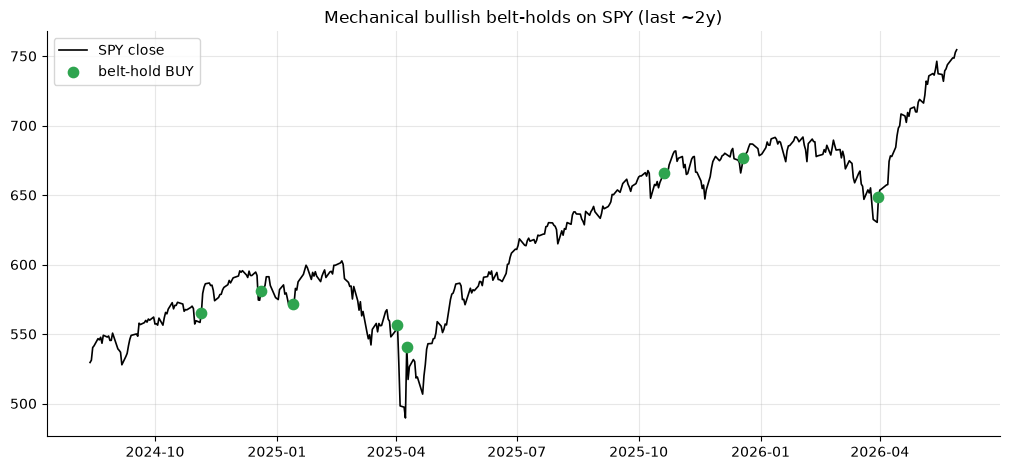

belt-hold signals in window: 8


In [2]:
b = load('SPY') if HAVE_REAL else None
if HAVE_REAL:
    seg = b.iloc[-450:]
    ent = st.belt_hold_entries(b); ent = ent[ent >= seg.index[0]]
    fig, ax = plt.subplots(figsize=(10.2, 4.8))
    ax.plot(seg.index, seg['close'].values, c='k', lw=1.2, label='SPY close')
    ax.scatter(ent, b['close'].reindex(ent), c=GREEN, s=55, zorder=5, label='belt-hold BUY')
    ax.set_title('Mechanical bullish belt-holds on SPY (last ~2y)'); ax.legend(loc='upper left')
    plt.tight_layout(); plt.show()
    print('belt-hold signals in window:', len(ent))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

The signals land on sharp up-days after dips — exactly as advertised. The question is whether those green dots are followed by *more* upside than buying on any old day. **Let's race the belt-hold against random entries** at four horizons. Blue = belt-hold; grey = random days.

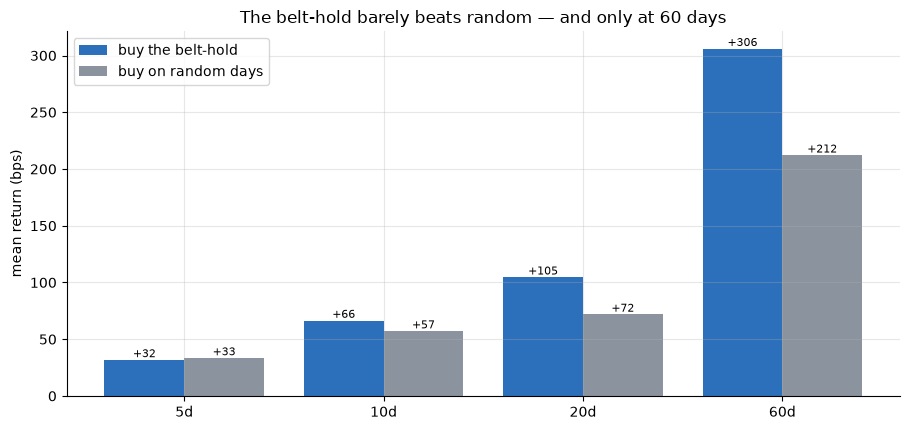

belt-hold: [32, 66, 105, 306]
random: [33, 57, 72, 212]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    bh, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            bb = load(t)
            e = st.belt_hold_entries(bb)
            re = st.random_entries(bb, max(len(e),50), seed=7)
            tt.append(st.forward_returns(bb, e, h)); rr.append(st.forward_returns(bb, re, h))
        bh.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    bh = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, bh, .4, color='#2c6fbb', label='buy the belt-hold')
ax.bar(x+.2, rnd, .4, color=GREY, label='buy on random days')
for i,(a,bb) in enumerate(zip(bh,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.set_title('The belt-hold barely beats random — and only at 60 days'); ax.legend()
plt.tight_layout(); plt.show()
print('belt-hold:', [round(v) for v in bh]); print('random:', [round(v) for v in rnd])

There's the whole story. The belt-hold makes money in absolute terms (**+105 bps** over 20 days) — but so does buying on **random days** (**+72 bps**). At 5/10/20 days it's a coin-flip. Only at 60 days does the belt-hold nose ahead (**+306** vs **+212** bps), and even then by a whisker (the quants notebook shows the *t* is just **+2.03**, right at the bar). Most of the apparent edge is **the market's upward drift**, not the candle.

**The decisive check.** What if we keep the **downtrend** but throw away the **candle shape** — buy *random bars in the same kind of downtrend* instead of the belt-hold? If the open-at-the-low really matters, the shape-blind version should do much worse.

In [4]:
if HAVE_REAL:
    c = load('SPY')
    pl = st.shape_scramble_placebo(c, 20, n_draws=300, seed=456)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real belt-hold (SPY, 20d): {obs:+.1f} bps')
print(f'... but {pval*100:.0f}% of *shape-scrambled* draws (random downtrend bars) do as well (p={pval:.2f}).')
print('=> the open-at-low candle shape is NOT doing the work.')

real belt-hold (SPY, 20d): +119.5 bps
... but 42% of *shape-scrambled* draws (random downtrend bars) do as well (p=0.42).
=> the open-at-low candle shape is NOT doing the work.


Nearly half of the **shape-scrambled** draws match or beat the real belt-hold (*p* = 0.43). If the open-at-the-extreme genuinely mattered, scrambling it would collapse the result. It doesn't — because whatever small edge exists is the **downtrend context**, not the candle.

## 5 · The verdict

- **Signal — Weak.** The belt-hold is a coin-flip vs random at 5/10/20 days and only *marginally* beats it at 60 days (*t* = +2.03, right at the bar) — concentrated in one name. Enough to deny a clean 'None', far short of a real edge.
- **Tradability — Fragile.** The only edge is slow (60-day), leans on a single instrument, and is really the downtrend context — not a deployable candle signal.
- **"Does the opening-at-extreme reverse"? — Busted.** Scramble the candle shape and the result barely moves (*p* = 0.43). The open-at-the-low isn't doing the reversing.

## 6 · Could you actually trade it?

Barely, and not as a *candle* strategy. The belt-hold's only edge over a coin flip shows up at 60 days, leans almost entirely on SPY, and is really 'buy a dip and wait' — which you'd capture more simply (and more fully) by just buying after downtrends, no candle screener required. Costs on every signal eat into an already-thin result. As a forecasting tool the open-at-the-low doesn't pay; as a labelling tool it was never meant to be a strategy.

## 7 · Going further 🚪

- **The downtrend, not the candle.** The placebo says the edge is the prior downtrend. A fun follow-up strips the candle entirely and just buys post-downtrend dips — same result, no belt-hold.
- **Tighter shapes.** Try a full marubozu (no wicks either end) or a body ≥80% of range — fewer signals, same story: drift/context in, candle out.
- **A real positive control.** The quants notebook plants a *genuine* belt-hold reversal into a synthetic tape and shows the harness banks it (so the marginal real result isn't a dead detector — it's an honest reading).

*Think the belt-hold forecasts? Show it beating random entries **and** its own shape-scramble placebo at **t ≥ 2** across horizons on a real tape — then we'll talk.*